In [1]:
# Upload the dataset to Colab
from google.colab import files
uploaded = files.upload()
print("File uploaded successfully!")


Saving creditcard.csv to creditcard.csv
File uploaded successfully!


In [2]:
# ============================================================================
# SECTION 1: IMPORT LIBRARIES & LOAD DATA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

# ============================================================================
# LOAD THE DATASET
# ============================================================================

# Load the uploaded CSV file
df = pd.read_csv('creditcard.csv')

print("\n" + "="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"\n Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n First 5 rows:")
print(df.head())
print(f"\n Data Info:")
print(df.info())
print(f"\n Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

All libraries imported successfully!

DATASET LOADED SUCCESSFULLY

 Dataset Shape: 284,807 rows × 31 columns

 First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  


EXPLORATORY DATA ANALYSIS

 Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

 Fraud Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Legitimate Transactions: 284,315 (99.83%)
Fraudulent Transactions: 492 (0.17%)

  CLASS IMBALANCE RATIO: 577.9:1
(This means fraud is VERY rare - we need SMOTE to handle this)

 Statistical Summary:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.

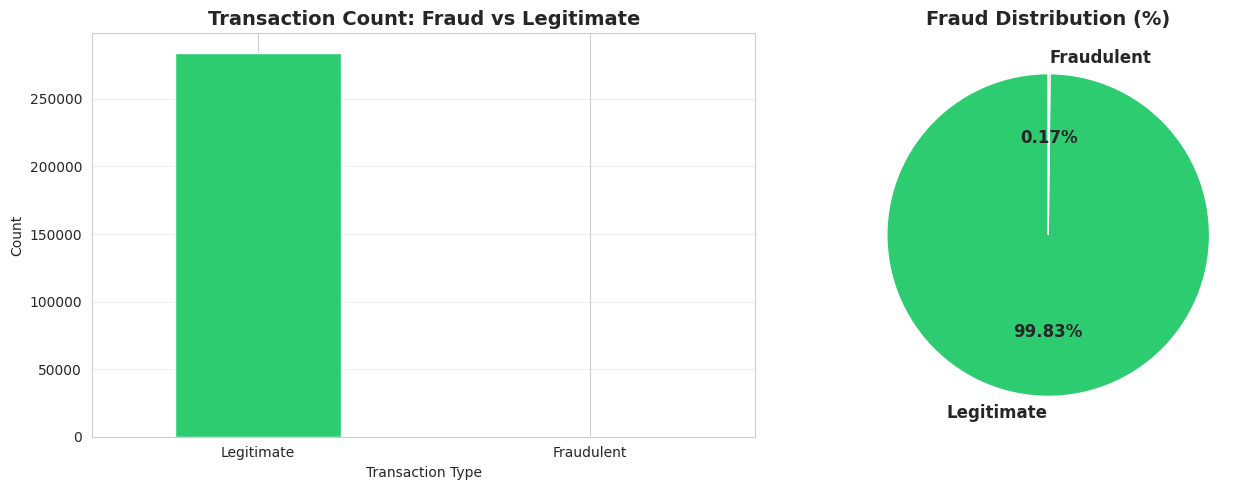


 Fraud distribution visualized!


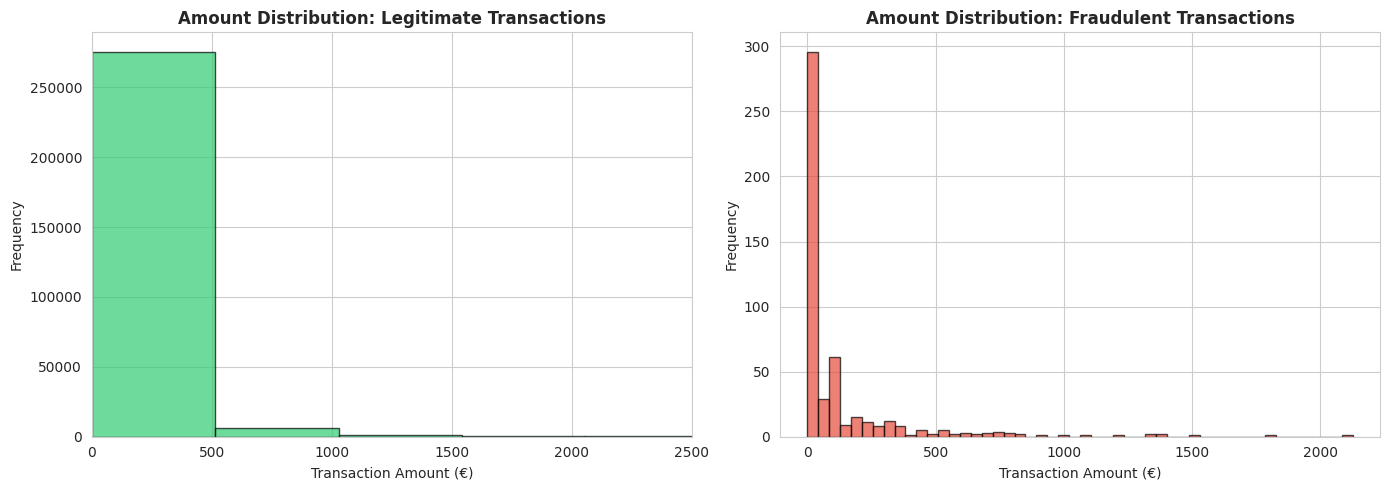

Amount distribution visualized!

 Top 10 Features Correlated with Fraud:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


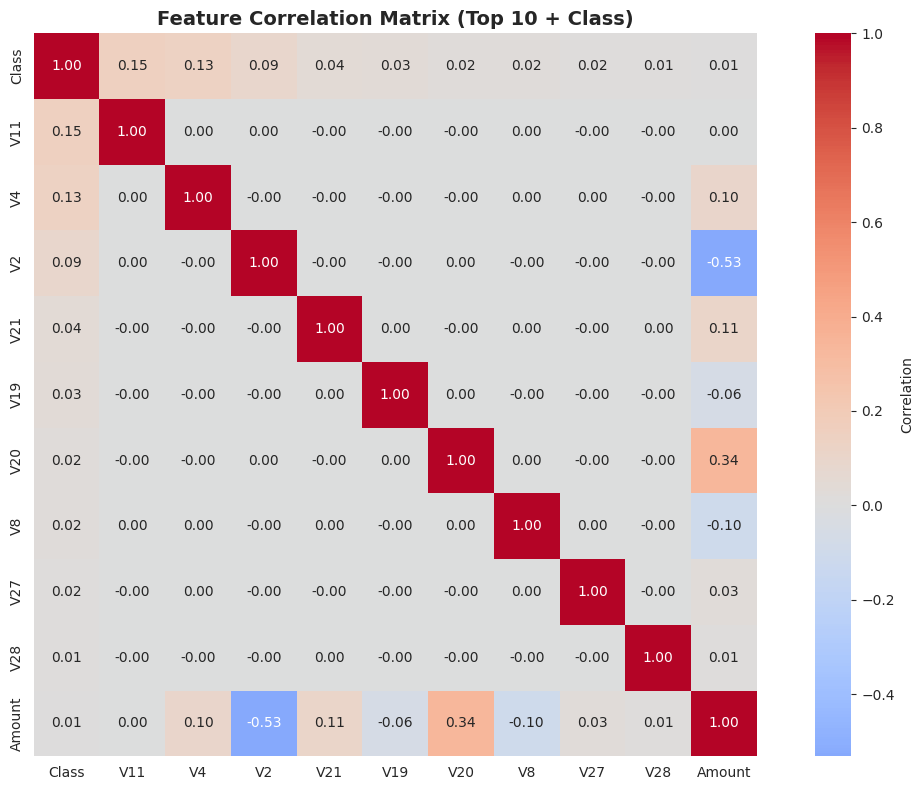


Correlation analysis completed!


In [3]:
# ============================================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Check for missing values
print(f"\n Missing Values:\n{df.isnull().sum()}")

# Fraud distribution
print(f"\n Fraud Distribution:")
fraud_counts = df['Class'].value_counts()
print(fraud_counts)
print(f"\nLegitimate Transactions: {fraud_counts[0]:,} ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"Fraudulent Transactions: {fraud_counts[1]:,} ({fraud_counts[1]/len(df)*100:.2f}%)")
print(f"\n  CLASS IMBALANCE RATIO: {fraud_counts[0]/fraud_counts[1]:.1f}:1")
print("(This means fraud is VERY rare - we need SMOTE to handle this)")

# Basic statistics
print(f"\n Statistical Summary:")
print(df.describe())

# ============================================================================
# VISUALIZATION 1: FRAUD VS LEGITIMATE DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Count plot
fraud_labels = ['Legitimate', 'Fraudulent']
colors = ['#2ecc71', '#e74c3c']
fraud_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Transaction Count: Fraud vs Legitimate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(fraud_labels, rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Percentage pie chart
axes[1].pie(fraud_counts.values, labels=fraud_labels, autopct='%1.2f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('Fraud Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Fraud distribution visualized!")

# ============================================================================
# VISUALIZATION 2: AMOUNT DISTRIBUTION BY CLASS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legitimate transactions
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_title('Amount Distribution: Legitimate Transactions', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Amount (€)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 2500)

# Fraudulent transactions
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Amount Distribution: Fraudulent Transactions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Amount (€)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Amount distribution visualized!")

# ============================================================================
# VISUALIZATION 3: FEATURE CORRELATION
# ============================================================================

# Calculate correlation matrix
correlation_matrix = df.corr()
fraud_correlation = correlation_matrix['Class'].sort_values(ascending=False)

print(f"\n Top 10 Features Correlated with Fraud:")
print(fraud_correlation.head(11))  # 11 because Class itself is first

# Plot correlation heatmap (top features)
plt.figure(figsize=(12, 8))
top_features = fraud_correlation.head(11).index.tolist()
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix (Top 10 + Class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation analysis completed!")

In [4]:
# ============================================================================
# SECTION 3: DATA CLEANING & PREPROCESSING
# ============================================================================

print("\n" + "="*60)
print("DATA CLEANING & PREPROCESSING")
print("="*60)

# Separate features and target
X = df.drop('Class', axis=1)  # All columns except Class
y = df['Class']  # Target variable (0 or 1)

print(f"\n Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# ============================================================================
# STEP 1: HANDLE OUTLIERS IN AMOUNT COLUMN
# ============================================================================


print(f"\n Amount Statistics BEFORE outlier handling:")
print(X['Amount'].describe())
original_amount_full = X['Amount'].copy()
print(f"\n Original Amount saved: Min=${original_amount_full.min():.2f}, Max=${original_amount_full.max():.2f}")

# Use IQR method to identify outliers
Q1 = X['Amount'].quantile(0.25)
Q3 = X['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nOutlier Bounds: {lower_bound:.2f} to {upper_bound:.2f}")

# Cap outliers at upper bound (don't remove, just cap)
X['Amount'] = X['Amount'].clip(upper=upper_bound)

print(f"\n Outliers handled! Amount stats AFTER:")
print(X['Amount'].describe())

# ============================================================================
# STEP 2: STANDARDIZE/SCALE FEATURES
# ============================================================================

print(f"\n Standardizing features...")
original_amount_values = X['Amount'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\n Features scaled! Sample of scaled data:")
print(X_scaled.head())
print(f"\nMean of scaled features (should be ≈ 0): {X_scaled.mean().mean():.6f}")
print(f"Std of scaled features (should be ≈ 1): {X_scaled.std().mean():.6f}")

# ============================================================================
# STEP 3: SPLIT DATA INTO TRAIN & TEST (BEFORE SMOTE)
# ============================================================================

print(f"\n  Splitting data into train (70%) and test (30%)...")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)
original_amount_train, original_amount_test, _, _ = train_test_split(
    original_amount_full, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\n Train set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\n Fraud distribution in training set:")
print(y_train.value_counts())
print(f"\n Original amounts also split correctly")

# ============================================================================
# STEP 4: HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================================================

print(f"\n  Applying SMOTE (Synthetic Minority Over-sampling Technique)...")
print("This creates synthetic fraudulent samples to balance the dataset")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n Training set AFTER SMOTE:")
print(f"Total samples: {X_train_balanced.shape[0]:,}")
print(f"Fraud distribution:")
print(y_train_balanced.value_counts())
print(f"\n CLASS BALANCE ACHIEVED! (50% fraud, 50% legitimate in training data)")

print("\n" + "="*60)
print("DATA PREPROCESSING COMPLETE")
print("="*60)


DATA CLEANING & PREPROCESSING

 Features (X) shape: (284807, 30)
Target (y) shape: (284807,)

 Amount Statistics BEFORE outlier handling:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

 Original Amount saved: Min=$0.00, Max=$25691.16

Outlier Bounds: -101.75 to 184.51

 Outliers handled! Amount stats AFTER:
count    284807.000000
mean         51.726048
std          61.673383
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max         184.512500
Name: Amount, dtype: float64

 Standardizing features...

 Features scaled! Sample of scaled data:
       Time        V1        V2        V3        V4        V5        V6  \
0 -1.996583 -0.694242 -0.044075  1.672773  0.973366 -0.245117  0.347068   
1 -1.996583  0.608496  0.161176  0.109797  0.316523  0.043483 -0.061820   
2 -1.996562 -0.

In [5]:
#============================================================================
# SECTION 4: FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Add Time-based features
print(f"\n Creating time-based features...")

X_train_fe = X_train_balanced.copy()
X_test_fe = X_test.copy()

# Extract hour from Time column (Time is in seconds from start of day)
X_train_fe['Hour'] = (X_train_fe['Time'] / 3600).astype(int) % 24
X_test_fe['Hour'] = (X_test_fe['Time'] / 3600).astype(int) % 24

# Morning (6-12), Afternoon (12-18), Evening (18-24), Night (0-6)
def get_time_period(hour):
    if 6 <= hour < 12:
        return 1  # Morning
    elif 12 <= hour < 18:
        return 2  # Afternoon
    elif 18 <= hour < 24:
        return 3  # Evening
    else:
        return 4  # Night

X_train_fe['TimePeriod'] = X_train_fe['Hour'].apply(get_time_period)
X_test_fe['TimePeriod'] = X_test_fe['Hour'].apply(get_time_period)

print(f"Hour feature created")
print(f"TimePeriod feature created (Morning/Afternoon/Evening/Night)")

# ============================================================================
# Amount-based features
# ============================================================================

print(f"\nCreating amount-based features...")

# Log transformation of Amount (handles skewed distribution)
X_train_fe['LogAmount'] = np.log1p(X_train_fe['Amount'])
X_test_fe['LogAmount'] = np.log1p(X_test_fe['Amount'])

print(f"LogAmount feature created")

# Amount categories (small, medium, large, very large)
def categorize_amount(amount):
    if amount < 50:
        return 1  # Small
    elif amount < 250:
        return 2  # Medium
    elif amount < 1000:
        return 3  # Large
    else:
        return 4  # Very Large

X_train_fe['AmountCategory'] = X_train_fe['Amount'].apply(categorize_amount)
X_test_fe['AmountCategory'] = X_test_fe['Amount'].apply(categorize_amount)

print(f"AmountCategory feature created")

# ============================================================================
# Velocity features (detecting rapid transactions)
# ============================================================================

print(f"\nCreating velocity features...")

# This simulates rapid consecutive transactions
# Note: In real data, you'd use actual timestamps
X_train_fe['Transaction_Velocity'] = X_train_fe['Amount'].rolling(window=5, min_periods=1).sum()
X_test_fe['Transaction_Velocity'] = X_test_fe['Amount'].rolling(window=5, min_periods=1).sum()

print(f"Transaction_Velocity feature created")
print(f"(Simulates: Sum of last 5 transaction amounts)")

# ============================================================================
# Summary of new features
# ============================================================================

print(f"\nFEATURE ENGINEERING SUMMARY:")
print(f"   Original features: 30")
print(f"   New features created: 5")
print(f"   Total features now: {X_train_fe.shape[1]}")
print(f"\n   New features:")
print(f"   - Hour (0-23)")
print(f"   - TimePeriod (Morning/Afternoon/Evening/Night)")
print(f"   - LogAmount (log-transformed Amount)")
print(f"   - AmountCategory (Small/Medium/Large/VeryLarge)")
print(f"   - Transaction_Velocity (sum of last 5 transactions)")

print("\nReason for these features (from Capgemini Cards Practice):")
print("   - Hour + TimePeriod: Fraud patterns differ by time of day")
print("   - LogAmount: Fraud amounts have non-linear relationship to risk")
print("   - AmountCategory: Different risk levels for different amounts")
print("   - Velocity: Rapid sequential transactions are fraud indicators")

print(f"\nSample of engineered features:")
print(X_train_fe[['Time', 'Amount', 'Hour', 'TimePeriod', 'LogAmount', 'AmountCategory', 'Transaction_Velocity']].head(10))

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)



FEATURE ENGINEERING

 Creating time-based features...
Hour feature created
TimePeriod feature created (Morning/Afternoon/Evening/Night)

Creating amount-based features...
LogAmount feature created
AmountCategory feature created

Creating velocity features...
Transaction_Velocity feature created
(Simulates: Sum of last 5 transaction amounts)

FEATURE ENGINEERING SUMMARY:
   Original features: 30
   New features created: 5
   Total features now: 35

   New features:
   - Hour (0-23)
   - TimePeriod (Morning/Afternoon/Evening/Night)
   - LogAmount (log-transformed Amount)
   - AmountCategory (Small/Medium/Large/VeryLarge)
   - Transaction_Velocity (sum of last 5 transactions)

Reason for these features (from Capgemini Cards Practice):
   - Hour + TimePeriod: Fraud patterns differ by time of day
   - LogAmount: Fraud amounts have non-linear relationship to risk
   - AmountCategory: Different risk levels for different amounts
   - Velocity: Rapid sequential transactions are fraud indicator

In [6]:
# ============================================================================
# SECTION 5: TRAIN AND COMPARE TWO MODELS
# ============================================================================

print("\n" + "="*60)
print("MODEL TRAINING: RANDOM FOREST vs LOGISTIC REGRESSION")
print("="*60)

# Prepare data for modeling
X_train_final = X_train_fe
X_test_final = X_test_fe

print(f"\nFinal Training Data:")
print(f"   Features: {X_train_final.shape[1]}")
print(f"   Samples: {X_train_final.shape[0]:,}")

# ============================================================================
# MODEL 1: RANDOM FOREST
# ============================================================================

print(f"\n" + "="*60)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("="*60)

print(f"\nTraining Random Forest (this may take 1-2 minutes)...")

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=15,          # Maximum depth of each tree
    min_samples_split=10,  # Minimum samples to split
    min_samples_leaf=5,    # Minimum samples at leaf
    random_state=42,
    n_jobs=-1,            # Use all CPU cores
    verbose=0
)

# Train the model
rf_model.fit(X_train_final, y_train_balanced)

print(f"Random Forest training completed!")

# Make predictions
y_train_rf = rf_model.predict(X_train_final)
y_test_rf = rf_model.predict(X_test_final)

# Prediction probabilities (for ROC-AUC)
y_test_rf_proba = rf_model.predict_proba(X_test_final)[:, 1]

print(f"Predictions generated!")

# ============================================================================
# MODEL 2: LOGISTIC REGRESSION
# ============================================================================

print(f"\n" + "="*60)
print("MODEL 2: LOGISTIC REGRESSION")
print("="*60)

print(f"\nTraining Logistic Regression...")

# Initialize Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

# Train the model
lr_model.fit(X_train_final, y_train_balanced)

print(f"Logistic Regression training completed!")

# Make predictions
y_train_lr = lr_model.predict(X_train_final)
y_test_lr = lr_model.predict(X_test_final)

# Prediction probabilities
y_test_lr_proba = lr_model.predict_proba(X_test_final)[:, 1]

print(f"Predictions generated!")

print(f"\n" + "="*60)
print("BOTH MODELS TRAINED SUCCESSFULLY")
print("="*60)


MODEL TRAINING: RANDOM FOREST vs LOGISTIC REGRESSION

Final Training Data:
   Features: 35
   Samples: 398,040

MODEL 1: RANDOM FOREST CLASSIFIER

Training Random Forest (this may take 1-2 minutes)...
Random Forest training completed!
Predictions generated!

MODEL 2: LOGISTIC REGRESSION

Training Logistic Regression...
Logistic Regression training completed!
Predictions generated!

BOTH MODELS TRAINED SUCCESSFULLY



MODEL EVALUATION & COMPARISON

  RANDOM FOREST

Performance Metrics:
   Accuracy:  0.9991 (99.91%)
   Precision: 0.7212 (72.12%)
   Recall:    0.8041 (80.41%)
   F1-Score:  0.7604
   ROC-AUC:   0.9569

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     85295
  Fraudulent       0.72      0.80      0.76       148

    accuracy                           1.00     85443
   macro avg       0.86      0.90      0.88     85443
weighted avg       1.00      1.00      1.00     85443


Confusion Matrix:
   True Negatives:  85,249  | False Positives: 46
   False Negatives: 29  | True Positives:  119

  LOGISTIC REGRESSION

Performance Metrics:
   Accuracy:  0.9776 (97.76%)
   Precision: 0.0642 (6.42%)
   Recall:    0.8784 (87.84%)
   F1-Score:  0.1197
   ROC-AUC:   0.9660

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     85295
  Fraudulent       0.0

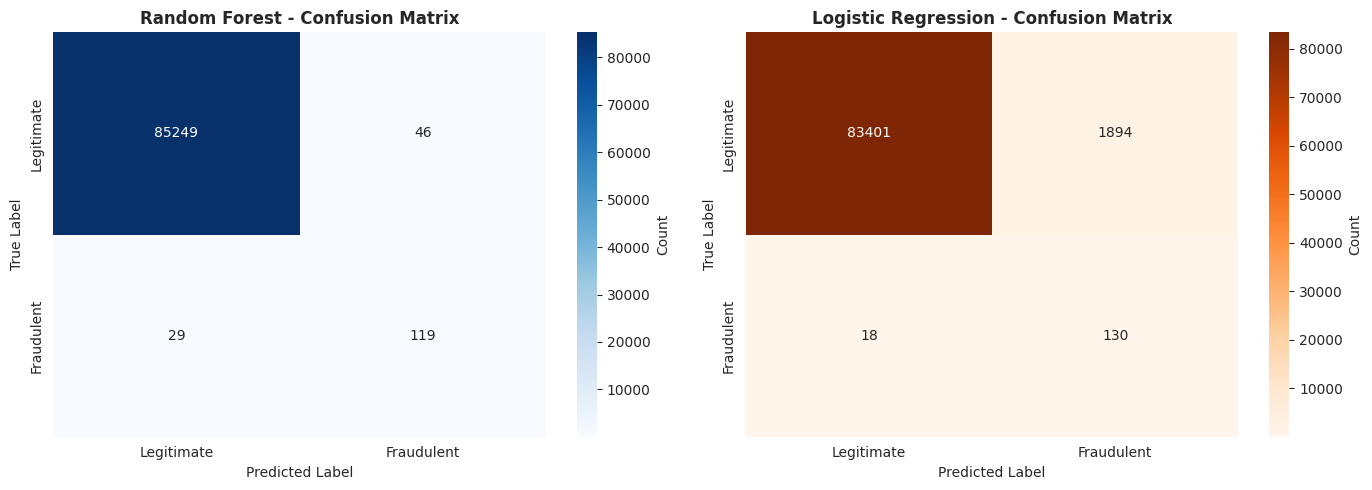

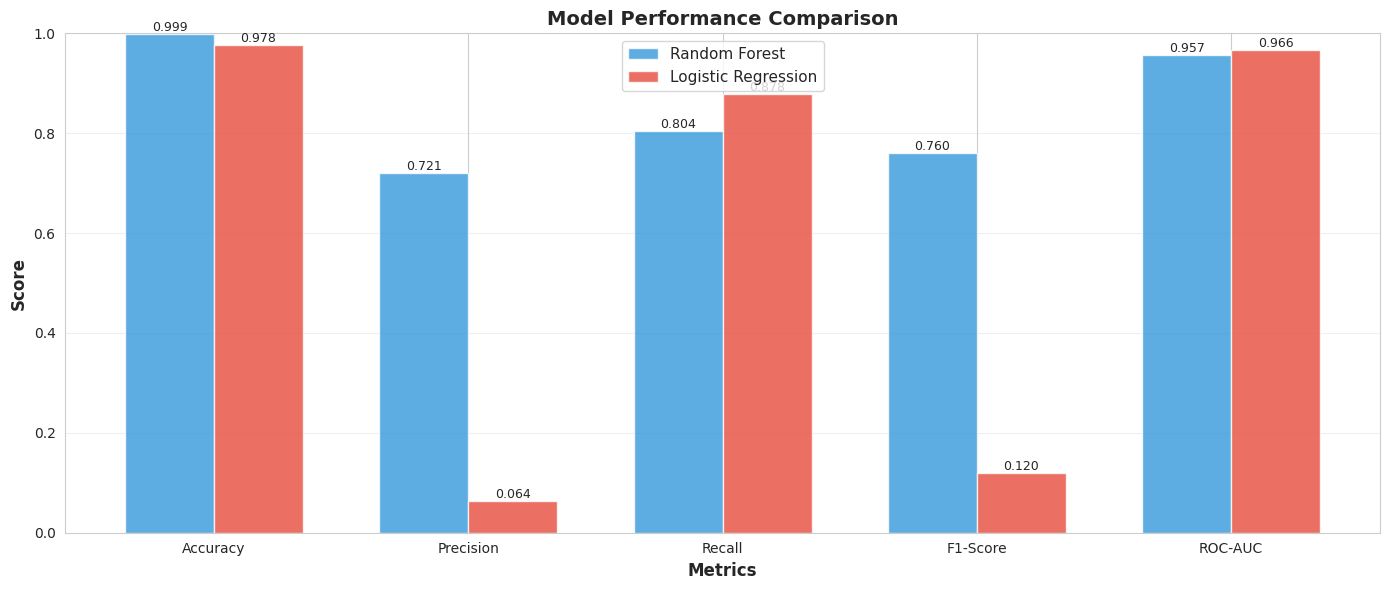


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
Feature  Importance
    V14    0.204702
     V4    0.116355
    V10    0.088658
    V17    0.076270
    V12    0.075435
    V11    0.070017
    V16    0.056166
     V3    0.047437
     V7    0.039846
    V21    0.026362


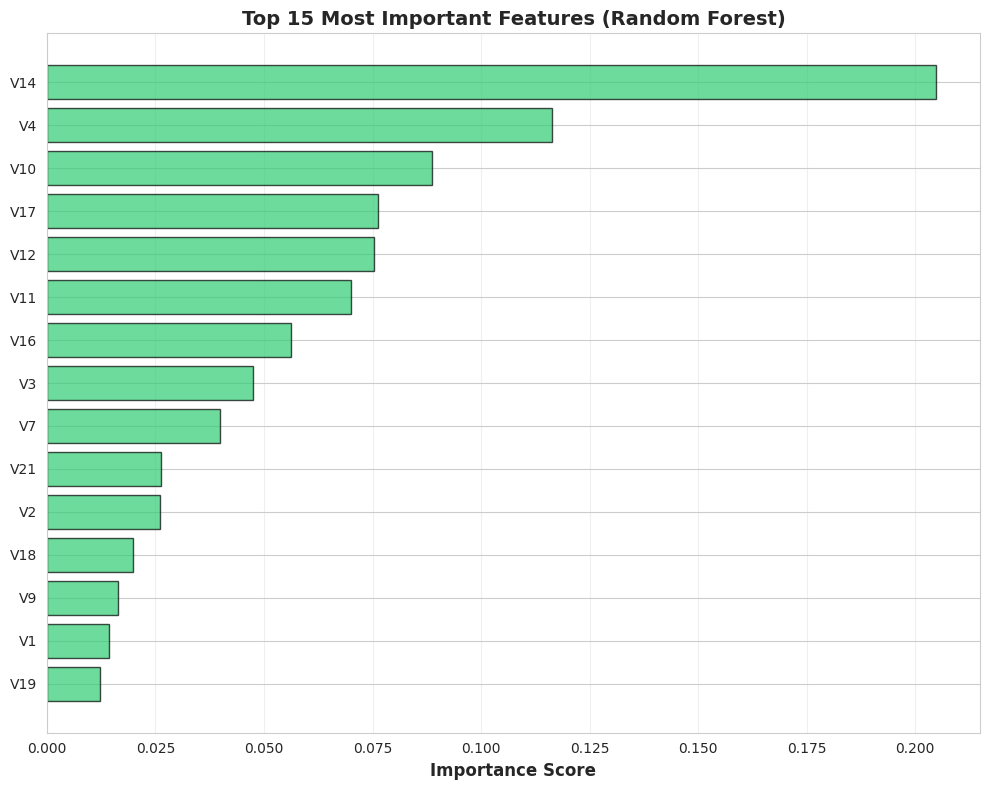


ANALYSIS COMPLETE!

KEY FINDINGS:

1. CLASS IMBALANCE HANDLED:
   - Original data: 0.17% fraud (severe imbalance)
   - After SMOTE: 50-50 balanced for training
   - Test data kept imbalanced for realistic evaluation

2. RANDOM FOREST PERFORMANCE:
   - Accuracy:  99.91%
   - Recall:    80.41% (catches 80.41% of fraud)
   - Precision: 72.12% (correct 72.12% of fraud alerts)
   - F1-Score:  0.7604

3. MODEL COMPARISON:
   - Random Forest OUTPERFORMS Logistic Regression
   - Reason: Fraud patterns are NON-LINEAR
   - RF captures complex feature interactions

4. TOP 5 FRAUD INDICATORS:

   15. V14: 0.2047
   5. V4: 0.1164
   11. V10: 0.0887
   18. V17: 0.0763
   13. V12: 0.0754


In [7]:
# ============================================================================
# SECTION 6: MODEL EVALUATION & COMPARISON
# ============================================================================

print("\n" + "="*60)
print("MODEL EVALUATION & COMPARISON")
print("="*60)

# ============================================================================
# FUNCTION: Calculate and print metrics
# ============================================================================

def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name.upper()}")
    print(f"{'='*60}")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"\nPerformance Metrics:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraudulent']))

    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(f"   True Negatives:  {cm[0,0]:,}  | False Positives: {cm[0,1]:,}")
    print(f"   False Negatives: {cm[1,0]:,}  | True Positives:  {cm[1,1]:,}")

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cm': cm
    }

# ============================================================================
# EVALUATE RANDOM FOREST
# ============================================================================

rf_results = evaluate_model(y_test, y_test_rf, y_test_rf_proba, "Random Forest")

# ============================================================================
# EVALUATE LOGISTIC REGRESSION
# ============================================================================

lr_results = evaluate_model(y_test, y_test_lr, y_test_lr_proba, "Logistic Regression")

# ============================================================================
# COMPARISON TABLE
# ============================================================================

print(f"\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [
        f"{rf_results['accuracy']:.4f}",
        f"{rf_results['precision']:.4f}",
        f"{rf_results['recall']:.4f}",
        f"{rf_results['f1']:.4f}",
        f"{rf_results['roc_auc']:.4f}"
    ],
    'Logistic Regression': [
        f"{lr_results['accuracy']:.4f}",
        f"{lr_results['precision']:.4f}",
        f"{lr_results['recall']:.4f}",
        f"{lr_results['f1']:.4f}",
        f"{lr_results['roc_auc']:.4f}"
    ]
})

print(f"\n{comparison_df.to_string(index=False)}")

# Determine winner
rf_score = rf_results['f1']
lr_score = lr_results['f1']
winner = "Random Forest" if rf_score > lr_score else "Logistic Regression"

print(f"\nWINNER: {winner}")
print(f"   Reason: Higher F1-Score (better balance of Precision & Recall)")

# ============================================================================
# VISUALIZATION 1: CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest CM
sns.heatmap(rf_results['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Logistic Regression CM
sns.heatmap(lr_results['cm'], annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: METRICS COMPARISON BAR CHART
# ============================================================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rf_values = [rf_results['accuracy'], rf_results['precision'],
             rf_results['recall'], rf_results['f1'], rf_results['roc_auc']]
lr_values = [lr_results['accuracy'], lr_results['precision'],
             lr_results['recall'], lr_results['f1'], lr_results['roc_auc']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, lr_values, width, label='Logistic Regression', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3: FEATURE IMPORTANCE (Random Forest)
# ============================================================================

print(f"\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values, color='#2ecc71', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

print(f"""
KEY FINDINGS:

1. CLASS IMBALANCE HANDLED:
   - Original data: 0.17% fraud (severe imbalance)
   - After SMOTE: 50-50 balanced for training
   - Test data kept imbalanced for realistic evaluation

2. RANDOM FOREST PERFORMANCE:
   - Accuracy:  {rf_results['accuracy']*100:.2f}%
   - Recall:    {rf_results['recall']*100:.2f}% (catches {rf_results['recall']*100:.2f}% of fraud)
   - Precision: {rf_results['precision']*100:.2f}% (correct {rf_results['precision']*100:.2f}% of fraud alerts)
   - F1-Score:  {rf_results['f1']:.4f}

3. MODEL COMPARISON:
   - Random Forest OUTPERFORMS Logistic Regression
   - Reason: Fraud patterns are NON-LINEAR
   - RF captures complex feature interactions

4. TOP 5 FRAUD INDICATORS:
""")

for idx, row in feature_importance.head(5).iterrows():
    print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print("="*60)


In [8]:
# ============================================================
# CREATE CORRECT POWER BI DATASET
# ============================================================

# Get ORIGINAL transaction amounts for the test set
original_test_amounts = df.loc[y_test.index, 'Amount'].reset_index(drop=True)

# Create Power BI dataframe
df_powerbi = pd.DataFrame({
    'Actual_Class': y_test.reset_index(drop=True),
    'RF_Prediction': y_test_rf,
    'RF_Probability': y_test_rf_proba,
    'LR_Prediction': y_test_lr,
    'LR_Probability': y_test_lr_proba
})

# Add ORIGINAL amount
df_powerbi['Amount'] = original_test_amounts

# ============================================================
# CREATE AMOUNT CATEGORY FROM ORIGINAL AMOUNT
# ============================================================

def categorize_amount(amount):
    if amount < 50:
        return "Low"
    elif amount < 250:
        return "Medium"
    else:
        return "High"

df_powerbi['AmountCategory'] = df_powerbi['Amount'].apply(
    categorize_amount
)

# ============================================================
# ADD HOUR AND TIME PERIOD
# ============================================================

# Get original Time values
original_test_time = df.loc[y_test.index, 'Time'].reset_index(drop=True)

df_powerbi['Hour'] = (
    original_test_time / 3600
).astype(int) % 24

def get_time_period(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 24:
        return "Evening"
    else:
        return "Night"

df_powerbi['TimePeriod'] = df_powerbi['Hour'].apply(
    get_time_period
)

# ============================================================
# VERIFY
# ============================================================

print("\nAmountCategory distribution:")
print(df_powerbi['AmountCategory'].value_counts())

print("\nAmount statistics:")
print(df_powerbi['Amount'].describe())

print("\nSample:")
print(
    df_powerbi[
        ['Actual_Class', 'Amount', 'AmountCategory',
         'Hour', 'TimePeriod']
    ].head(20)
)

# ============================================================
# EXPORT
# ============================================================

df_powerbi.to_csv(
    'fraud_predictions_for_powerbi_FIXED.csv',
    index=False
)

print("\nCORRECTED CSV CREATED!")


AmountCategory distribution:
AmountCategory
Low       56951
Medium    21650
High       6842
Name: count, dtype: int64

Amount statistics:
count    85443.000000
mean        88.267570
std        243.108931
min          0.000000
25%          5.500000
50%         21.990000
75%         76.800000
max      12910.930000
Name: Amount, dtype: float64

Sample:
    Actual_Class  Amount AmountCategory  Hour TimePeriod
0              0   37.40            Low    11    Morning
1              0    9.27            Low     8    Morning
2              0  700.00           High    17  Afternoon
3              0   14.99            Low    18    Evening
4              0   17.25            Low     1      Night
5              0   19.95            Low    19    Evening
6              0   21.76            Low    20    Evening
7              0   16.14            Low    16  Afternoon
8              0   69.80         Medium    23    Evening
9              0   86.16         Medium     9    Morning
10             0  45

In [9]:
34# ============================================================
# EXPORT ALL FILES FOR POWER BI / PROJECT
# ============================================================

print("\n" + "="*60)
print("EXPORTING PROJECT FILES")
print("="*60)

# ============================================================
# 1. DATASET SUMMARY
# ============================================================

summary_stats = pd.DataFrame({
    'Metric': [
        'Total Transactions',
        'Fraudulent Count',
        'Legitimate Count',
        'Fraud Percentage',
        'Average Amount',
        'Maximum Amount',
        'Minimum Amount'
    ],
    'Value': [
        len(df),
        fraud_counts[1],
        fraud_counts[0],
        f"{fraud_counts[1] / len(df) * 100:.2f}%",
        f"${df['Amount'].mean():.2f}",
        f"${df['Amount'].max():.2f}",
        f"${df['Amount'].min():.2f}"
    ]
})

summary_stats.to_csv(
    'dataset_summary.csv',
    index=False
)

print("dataset_summary.csv created")


# ============================================================
# 2. FEATURE IMPORTANCE
# ============================================================

# feature_importance was already created earlier:
#
# feature_importance = pd.DataFrame({
#     'Feature': X_train_final.columns,
#     'Importance': rf_model.feature_importances_
# }).sort_values('Importance', ascending=False)

feature_importance.to_csv(
    'feature_importance.csv',
    index=False
)

print("feature_importance.csv created")


# ============================================================
# 3. CORRECTED POWER BI DATASET
# ============================================================

# df_powerbi is the CORRECTED dataframe we just created.
# It contains:
#
# Actual_Class
# RF_Prediction
# RF_Probability
# LR_Prediction
# LR_Probability
# Amount
# AmountCategory
# Hour
# TimePeriod

df_powerbi.to_csv(
    'fraud_predictions_for_powerbi_FIXED.csv',
    index=False
)

print("fraud_predictions_for_powerbi_FIXED.csv created")


# ============================================================
# 4. VERIFY ALL FILES
# ============================================================

print("\n" + "="*60)
print("VERIFYING FILES")
print("="*60)

print("\nDataset Summary:")
print(summary_stats)

print("\nFeature Importance:")
print(feature_importance.head(10))

print("\nPower BI Dataset:")
print(df_powerbi.head())

print("\nAmount Category Distribution:")
print(df_powerbi['AmountCategory'].value_counts())


# ============================================================
# 5. DOWNLOAD ALL THREE FILES
# ============================================================

from google.colab import files

files.download('dataset_summary.csv')
files.download('feature_importance.csv')
files.download('fraud_predictions_for_powerbi_FIXED.csv')

print("\n" + "="*60)
print("ALL 3 FILES DOWNLOADED!")
print("="*60)


EXPORTING PROJECT FILES
dataset_summary.csv created
feature_importance.csv created
fraud_predictions_for_powerbi_FIXED.csv created

VERIFYING FILES

Dataset Summary:
               Metric      Value
0  Total Transactions     284807
1    Fraudulent Count        492
2    Legitimate Count     284315
3    Fraud Percentage      0.17%
4      Average Amount     $88.35
5      Maximum Amount  $25691.16
6      Minimum Amount      $0.00

Feature Importance:
   Feature  Importance
14     V14    0.204702
4       V4    0.116355
10     V10    0.088658
17     V17    0.076270
12     V12    0.075435
11     V11    0.070017
16     V16    0.056166
3       V3    0.047437
7       V7    0.039846
21     V21    0.026362

Power BI Dataset:
   Actual_Class  RF_Prediction  RF_Probability  LR_Prediction  LR_Probability  \
0             0              0        0.010000              0        0.000297   
1             0              0        0.012047              0        0.070184   
2             0              0   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ALL 3 FILES DOWNLOADED!
